In [ ]:
# ============================
# CHUNK 1: LOAD DATA (SAFE)
# ============================

import torch
from torch.utils.data import Dataset, DataLoader
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/processed_dataset_full_v1.pt"

assert os.path.exists(DATA_PATH), "Dataset not found"

class MyDataset(Dataset):
    def __init__(self, path):
        self.data = torch.load(path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        d = self.data[i]
        return d["seq"], d["rg"], d["dist"]

dataset = MyDataset(DATA_PATH)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dataset size:", len(dataset))

Mounted at /content/drive
Dataset size: 800


In [ ]:
# ============================
# CHUNK 2: MODELS
# ============================

import torch.nn as nn

# -------- TEACHER (SPATIAL MODEL) --------
class SpatialModel(nn.Module):
    def __init__(self):
        super().__init__()
        d_model = 96

        self.embedding = nn.Embedding(6, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=4, dim_feedforward=192, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, 2)

        self.seq_head = nn.Linear(d_model, 1)

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.dist_head = nn.Linear(16, 1)

        self.fusion = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, seq, dist):
        h = self.embedding(seq)
        h = self.transformer(h).mean(dim=1)
        rg_seq = self.seq_head(h).squeeze(-1)

        d = dist.unsqueeze(1)
        feat = self.cnn(d).view(d.size(0), -1)
        rg_dist = self.dist_head(feat).squeeze(-1)

        fused = torch.stack([rg_seq, rg_dist], dim=1)
        return self.fusion(fused).squeeze(-1)


# -------- STUDENT (SEQUENCE ONLY) --------
class SeqRgModel(nn.Module):
    def __init__(self):
        super().__init__()
        d_model = 128

        self.embedding = nn.Embedding(6, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            dim_feedforward=256,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(enc_layer, 3)

        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        h = self.embedding(x)
        h = self.transformer(h)
        h = h.mean(dim=1)
        return self.head(h).squeeze(-1)

In [ ]:
#train teacher
# ============================
# QUICK TEACHER TRAIN
# ============================

teacher = SpatialModel().to(device)
opt = torch.optim.Adam(teacher.parameters(), lr=3e-4)

for epoch in range(5):  # small just to get working
    teacher.train()
    total = 0

    for x, y, dist in loader:
        x, y, dist = x.to(device), y.to(device), dist.to(device)

        pred = teacher(x, dist)
        loss = torch.nn.functional.mse_loss(pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()

    print(f"Teacher Epoch {epoch+1}, Loss: {total/len(loader):.4f}")

torch.save(teacher.state_dict(), "spatial_model_v1.pt")
print("Teacher saved.")

Teacher Epoch 1, Loss: 478.7017
Teacher Epoch 2, Loss: 3.3213
Teacher Epoch 3, Loss: 3.2758
Teacher Epoch 4, Loss: 2.7640
Teacher Epoch 5, Loss: 2.2406
Teacher saved.


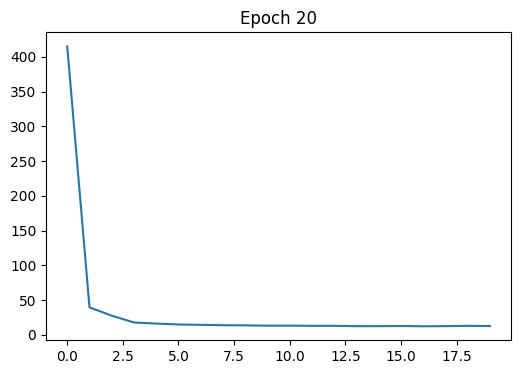

Loss: 12.5266
Pred std: 5.150
Corr: 0.819
ETA: 1.5s
Saved: seq_model_distilled_v1.pt


In [ ]:
# ============================
# CHUNK 3: TRAIN (DISTILLATION)
# ============================

import torch.nn.functional as F
from IPython.display import clear_output
import matplotlib.pyplot as plt
import time

# load teacher safely
teacher_path = "spatial_model_v1.pt"
assert os.path.exists(teacher_path), "Train spatial model first!"

teacher = SpatialModel().to(device)
teacher.load_state_dict(torch.load(teacher_path))
teacher.eval()

# student
student = SeqRgModel().to(device)
optimizer = torch.optim.Adam(student.parameters(), lr=3e-4)

epochs = 20
lambda_distill = 0.7
train_losses = []

def corr_loss(pred, target):
    pred = pred - pred.mean()
    target = target - target.mean()
    return - (pred * target).mean() / (pred.std() * target.std() + 1e-8)

for epoch in range(epochs):
    student.train()
    total_loss = 0

    all_preds = []
    all_true = []

    start = time.time()

    for i, (x, y, dist) in enumerate(loader):
        x, y, dist = x.to(device), y.to(device), dist.to(device)

        # teacher (no grad)
        with torch.no_grad():
            teacher_pred = teacher(x, dist)

        # student
        pred = student(x)

        # losses
        loss_true = F.mse_loss(pred, y)
        loss_teacher = F.mse_loss(pred, teacher_pred)

        loss = (1 - lambda_distill) * loss_true + lambda_distill * loss_teacher
        loss += 0.2 * corr_loss(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        all_preds.append(pred.detach().cpu())
        all_true.append(y.detach().cpu())

        # live tracking (lightweight)
        if i % 10 == 0:
            clear_output(wait=True)

            preds = torch.cat(all_preds)
            trues = torch.cat(all_true)

            avg_loss = total_loss / (i + 1)
            pred_std = preds.std().item()
            corr = torch.corrcoef(torch.stack([preds, trues]))[0,1].item()

            elapsed = time.time() - start
            eta = (len(loader)-i)/((i+1)/(elapsed+1e-8))

            plt.figure(figsize=(6,4))
            plt.plot(train_losses + [avg_loss])
            plt.title(f"Epoch {epoch+1}")
            plt.show()

            print(f"Loss: {avg_loss:.4f}")
            print(f"Pred std: {pred_std:.3f}")
            print(f"Corr: {corr:.3f}")
            print(f"ETA: {eta:.1f}s")

    train_losses.append(total_loss / len(loader))

# safe save
save_path = "seq_model_distilled_v1.pt"
torch.save(student.state_dict(), save_path)
print("Saved:", save_path)

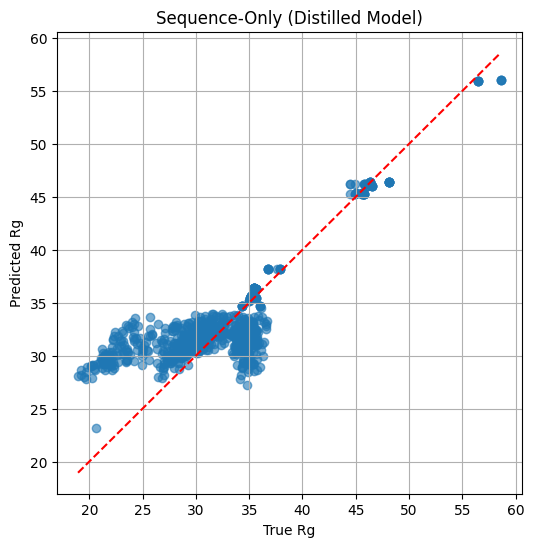

MAE: 2.784
RMSE: 3.714
Correlation: 0.838
Pred std: 4.878


In [ ]:
# ============================
# CHUNK 4: EVAL
# ============================

model = SeqRgModel().to(device)
model.load_state_dict(torch.load("seq_model_distilled_v1.pt"))
model.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for x, y, dist in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)

        all_true.append(y.cpu())
        all_pred.append(pred.cpu())

all_true = torch.cat(all_true)
all_pred = torch.cat(all_pred)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(all_true, all_pred, alpha=0.6)

minv = min(all_true.min(), all_pred.min())
maxv = max(all_true.max(), all_pred.max())

plt.plot([minv, maxv], [minv, maxv], 'r--')

plt.xlabel("True Rg")
plt.ylabel("Predicted Rg")
plt.title("Sequence-Only (Distilled Model)")

plt.grid()
plt.show()

mae = (all_true - all_pred).abs().mean().item()
rmse = torch.sqrt(((all_true - all_pred)**2).mean()).item()
corr = torch.corrcoef(torch.stack([all_true, all_pred]))[0,1].item()

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Correlation: {corr:.3f}")
print(f"Pred std: {all_pred.std().item():.3f}")